In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Path to dataset files: /kaggle/input/plantvillage


In [5]:
!pip install tensorflow

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Conv2D,MaxPooling2D,Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
print(os.listdir(path))

['PlantVillage']


In [8]:
# main_dir=path + "/PlantVillage"

main_dir = os.path.join(path, "PlantVillage")
print("Folders inside the PlantVillage : ",os.listdir(main_dir))

Folders inside the PlantVillage :  ['val', 'train']


In [9]:
train_dir=os.path.join(main_dir,"train")
val_dir=os.path.join(main_dir,"val")

In [10]:
print("Training images path : ",train_dir)
print("Validation and testing images path : ",val_dir)

Training images path :  /kaggle/input/plantvillage/PlantVillage/train
Validation and testing images path :  /kaggle/input/plantvillage/PlantVillage/val


In [11]:
print(os.listdir(train_dir)[:5])

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [12]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8,1.2]
)
val_test_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.5
)

In [13]:
image_size=(128,128)
batch_size=32
seed_value=942

train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=seed_value
)

val_generator=val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value,
    subset='training'
)

test_generator=val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=seed_value,
    subset='validation'
)

Found 43444 images belonging to 38 classes.
Found 5439 images belonging to 38 classes.
Found 5422 images belonging to 38 classes.


In [14]:
print("Training images count : ",train_generator.samples)
print("Validation images count : ",val_generator.samples)
print("Test images count : ",test_generator.samples)
print()
print("No:of Classes : ",train_generator.num_classes)
print("Classes and it's label : ",train_generator.class_indices)
print()
class_names=list(train_generator.class_indices.keys())

for i,names in enumerate(class_names):
  print(i,names)

Training images count :  43444
Validation images count :  5439
Test images count :  5422

No:of Classes :  38
Classes and it's label :  {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_

In [15]:
print(train_generator.class_indices==val_generator.class_indices)
print(train_generator.class_indices==test_generator.class_indices)

True
True


In [16]:
images , labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 128, 128, 3)
(32, 38)


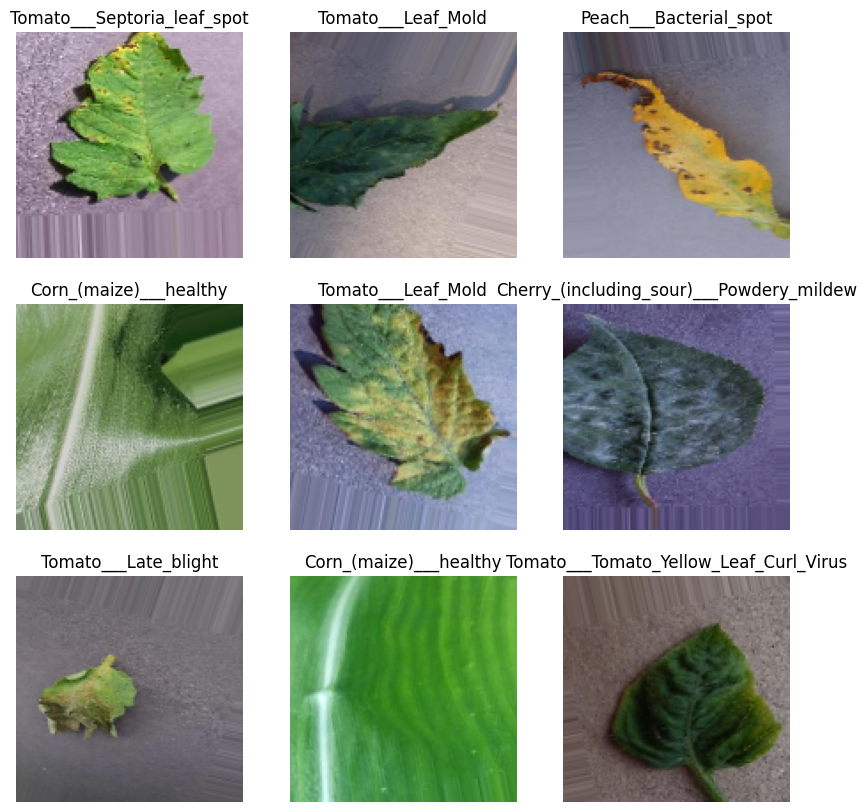

In [17]:
plt.figure(figsize=(10,10))

for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(images[i])

  class_index=np.argmax(labels[i])

  plt.title(class_names[class_index])
  plt.axis('off')

plt.show()


## Building the cnn neural network

In [20]:
model = Sequential()

model.add(keras.Input(shape=(128,128,3)))

model.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.4))

model.add(Dense(64,activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(train_generator.num_classes,activation="softmax"))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         1,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,299,270 (16.40 MB)

 Trainable params: 4,299,270 (16.40 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping=EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=2
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    train_generator,
    epochs=33,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 467s 335ms/step - accuracy: 0.2700 - loss: 2.7296 - val_accuracy: 0.4482 - val_loss: 1.9215
Epoch 2/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 327s 241ms/step - accuracy: 0.4465 - loss: 1.9735 - val_accuracy: 0.6003 - val_loss: 1.3982
Epoch 3/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 284s 209ms/step - accuracy: 0.5395 - loss: 1.6027 - val_accuracy: 0.6503 - val_loss: 1.1718
Epoch 4/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 280s 206ms/step - accuracy: 0.5968 - loss: 1.3856 - val_accuracy: 0.7106 - val_loss: 0.9862
Epoch 5/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 276s 204ms/step - accuracy: 0.6433 - loss: 1.2113 - val_accuracy: 0.7693 - val_loss: 0.7398
Epoch 6/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 276s 204ms/step - accuracy: 0.6671 - loss: 1.1197 - val_accuracy: 0.7762 - val_loss: 0.7089
Epoch 7/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 285s 210ms/step - accuracy: 0.6849 - loss: 1.0438 - val_accuracy: 0.7496 - val_loss: 0.7949
Epoch 8/33
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 276s 204ms/step - ac

In [23]:
model.evaluate(test_generator)

170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.9174 - loss: 0.2934


[0.2933746576309204, 0.9173736572265625]

In [24]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = test_generator.classes

cm = tf.math.confusion_matrix(
    labels=true_labels,
    predictions=predicted_labels
)

170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step


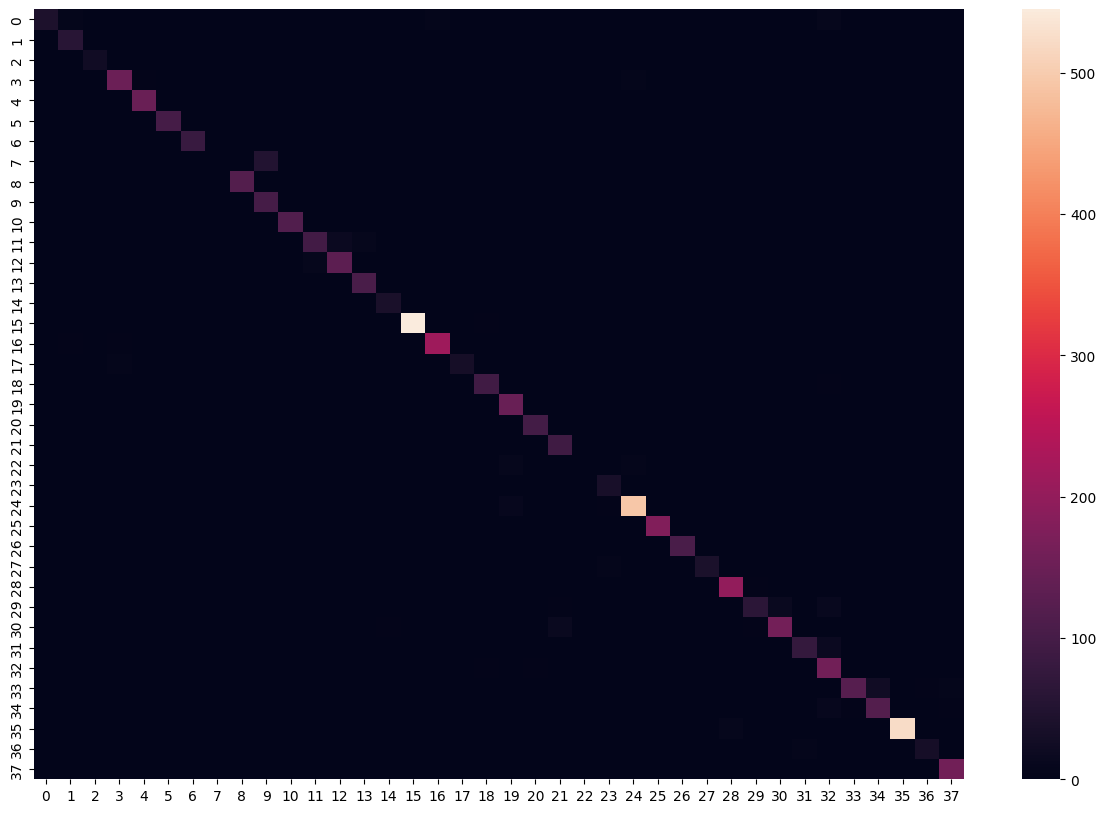

In [35]:
plt.figure(figsize=(15,10))
sns.heatmap(
    cm,
    annot=False
)
plt.show()

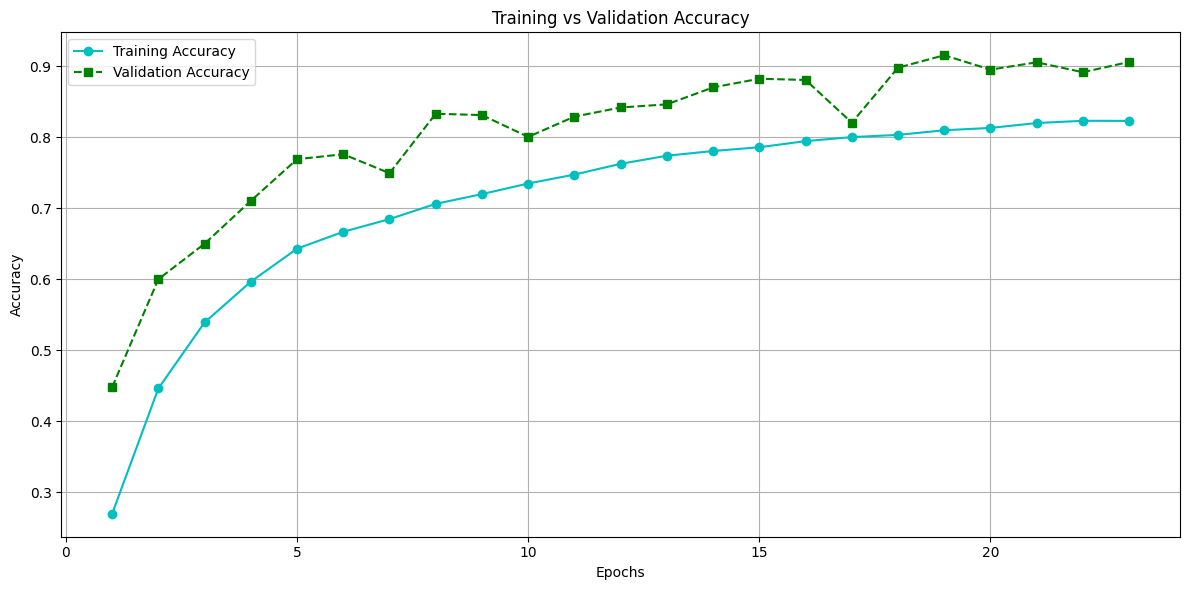

In [38]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(12,6))
plt.plot(epochs_range, history.history["accuracy"],marker="o",linestyle="-",color='c',label="Training Accuracy")
plt.plot(epochs_range, history.history["val_accuracy"],marker="s",linestyle="--",color='g',label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

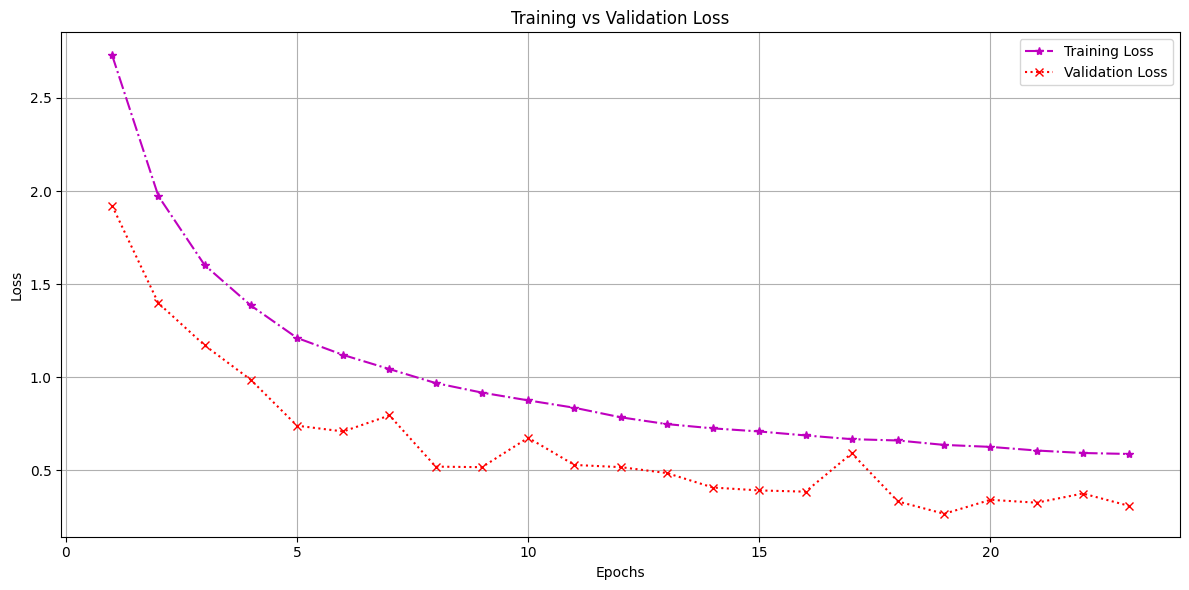

In [39]:
epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(12,6))
plt.plot(epochs_range, history.history["loss"],marker="*",linestyle="-.",color='m', label="Training Loss")
plt.plot(epochs_range, history.history["val_loss"],marker="x",linestyle=":",color='r', label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [28]:
model.save("plant_disease_model.keras")